# Notebook 4: Modelo de referencia SARIMA

Este notebook implementa un modelo SARIMA (Seasonal AutoRegressive 
Integrated Moving Average) que servirá como **modelo de referencia** 
frente al modelo principal Prophet desarrollado en el notebook 3.

El objetivo no es construir el modelo con mejor rendimiento posible, 
sino disponer de un punto de comparación basado en una técnica 
estadística clásica ampliamente utilizada en el análisis de series 
temporales. Esto permite contextualizar los resultados de Prophet 
frente a una alternativa establecida.

A diferencia del notebook 3, donde se exploraron diversas variantes 
del modelo con regresores externos, en este notebook se trabajará con 
SARIMA en su forma más sencilla: solo la serie temporal de pedidos, 
sin variables exógenas. SARIMA puro es la implementación clásica 
del modelo y la referencia más reconocida en la literatura de series temporales.


La metodología de evaluación será la misma que en el notebook 3 
(división cronológica con conjunto de test reservado y validación 
cruzada temporal), garantizando que las métricas sean directamente 
comparables.

## 1. Configuración inicial

Se importan las librerías necesarias y se carga el dataset 
enriquecido generado en el notebook 2.

In [32]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from pathlib import Path

# Suprimimos warnings de convergencia de modelos estadísticos
# para mantener limpia la salida
warnings.filterwarnings("ignore")

# Configuración de matplotlib para gráficas con estilo coherente
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Carga del dataset

Se carga el dataset enriquecido. SARIMA solo necesita la serie 
temporal de pedidos (sin regresores), pero se carga el dataset 
completo para mantener coherencia con los demás notebooks y poder 
acceder a los festivos en caso de querer ampliar el modelo más 
adelante.

In [33]:
# Cargamos el dataset enriquecido generado en el notebook 2
df = pd.read_csv(
    "../data/processed/dataset_enriquecido.csv",
    parse_dates=["fecha"]
)

# Inspección básica
print(f"Total de días: {len(df):,}")
print(f"Rango temporal: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"\nPrimeras filas:")
print(df.head())

Total de días: 1,067
Rango temporal: 2016-09-01 a 2019-08-03

Primeras filas:
       fecha  n_pedidos  es_festivo festivo_nombre  temp_media_dia  \
0 2016-09-01         10           0            NaN           17.42   
1 2016-09-02         20           0            NaN           17.14   
2 2016-09-03         35           0            NaN           16.83   
3 2016-09-04         12           0            NaN           17.96   
4 2016-09-05          5           0            NaN           17.86   

   precipitacion_total_dia  viento_medio_dia  humedad_media_dia  \
0                      0.0              9.65              73.38   
1                      1.3             14.96              82.58   
2                      2.8             17.54              81.54   
3                      0.6             20.36              75.00   
4                      2.4              9.07              87.17   

   nubosidad_media_dia  temp_media_serv  precipitacion_total_serv  \
0                68.83       

## 3. Análisis exploratorio de la serie

Antes de aplicar SARIMA, es necesario analizar las propiedades 
estadísticas de la serie temporal de pedidos. Concretamente:

- **Estacionariedad**: SARIMA asume que la serie de entrada (o su 
  diferenciación) es estacionaria, es decir, que sus propiedades 
  estadísticas no varían sistemáticamente con el tiempo. Una serie 
  con tendencia clara o cambios de varianza no es estacionaria y 
  requiere transformaciones previas.

- **Estacionalidad**: el componente estacional de SARIMA requiere 
  que se identifique el periodo de los patrones recurrentes. En el 
  caso de los pedidos diarios, el patrón semanal (S=7) es el más 
  evidente.

### 3.1. Visualización de la serie completa

Una primera inspección visual permite identificar de forma 
cualitativa los patrones presentes en la serie.

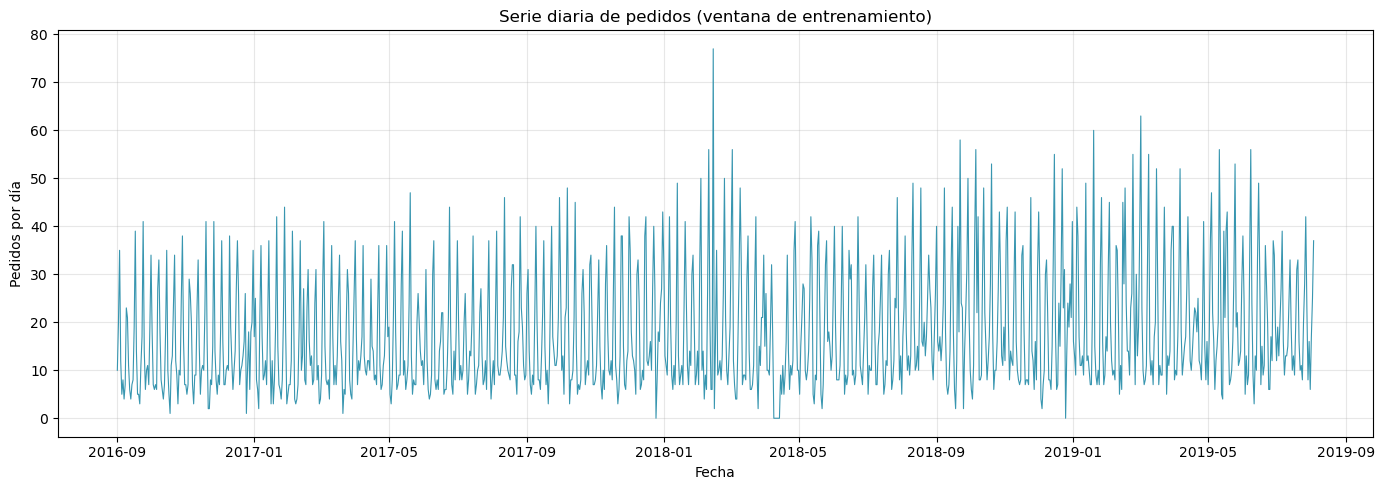

In [34]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["fecha"], df["n_pedidos"], color="#3896b0", linewidth=0.8)
ax.set_title("Serie diaria de pedidos (ventana de entrenamiento)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
plt.tight_layout()
plt.show()

### 3.2. Test estadístico de estacionariedad

El test de **Dickey-Fuller aumentado** (ADF) es el contraste estándar 
para evaluar la estacionariedad de una serie temporal. La hipótesis 
nula del test es que la serie tiene una raíz unitaria (es decir, que 
**no es estacionaria**). Si el p-valor del test es inferior a 0,05, se 
rechaza la hipótesis nula y se considera la serie estacionaria.

In [35]:
from statsmodels.tsa.stattools import adfuller

# Aplicamos el test ADF sobre la serie original
resultado = adfuller(df["n_pedidos"])

# Mostramos los resultados de forma legible
print("Test de Dickey-Fuller aumentado (ADF)")
print("=" * 50)
print(f"Estadístico ADF:  {resultado[0]:.4f}")
print(f"p-valor:          {resultado[1]:.6f}")
print(f"Lags utilizados:  {resultado[2]}")
print(f"Observaciones:    {resultado[3]}")
print(f"\nValores críticos:")
for clave, valor in resultado[4].items():
    print(f"  {clave}: {valor:.4f}")
print()
if resultado[1] < 0.05:
    print("Conclusión: se rechaza la hipótesis nula.")
    print("La serie es estacionaria (no requiere diferenciación).")
else:
    print("Conclusión: NO se rechaza la hipótesis nula.")
    print("La serie NO es estacionaria (requiere diferenciación).")

Test de Dickey-Fuller aumentado (ADF)
Estadístico ADF:  -3.5876
p-valor:          0.006002
Lags utilizados:  20
Observaciones:    1046

Valores críticos:
  1%: -3.4366
  5%: -2.8643
  10%: -2.5682

Conclusión: se rechaza la hipótesis nula.
La serie es estacionaria (no requiere diferenciación).


### 3.3. Diferenciación de la serie

Aunque el test ADF de la sección anterior indica que la serie es 
estacionaria, conviene completar el diagnóstico mirando cómo se 
comporta la serie una vez que se le quita la tendencia. La inspección 
visual deja ver que los pedidos diarios crecen de forma sostenida 
durante el periodo analizado (de unos 13 al inicio en 2016 a 22 al 
final en 2019), un crecimiento que el fuerte patrón semanal del 
negocio no impide pero que sí podría enmascarar parcialmente en el 
resultado del test.

Como diagnóstico adicional, se trabaja con la serie diferenciada: 
en lugar de mirar el número de pedidos de cada día, se mira la 
diferencia entre el día actual y el anterior. Esta transformación 
elimina la tendencia y deja a la vista las correlaciones de fondo 
que el crecimiento general podía estar tapando, lo que facilita el 
análisis de las gráficas de autocorrelación de la sección siguiente.

El grado de diferenciación definitivo del modelo SARIMA no se fija 
aquí. Esa decisión se delega a la función `auto_arima` de la 
sección 4, que aplica el test ADF internamente y elige el valor que 
mejor equilibra precisión y simplicidad del modelo.

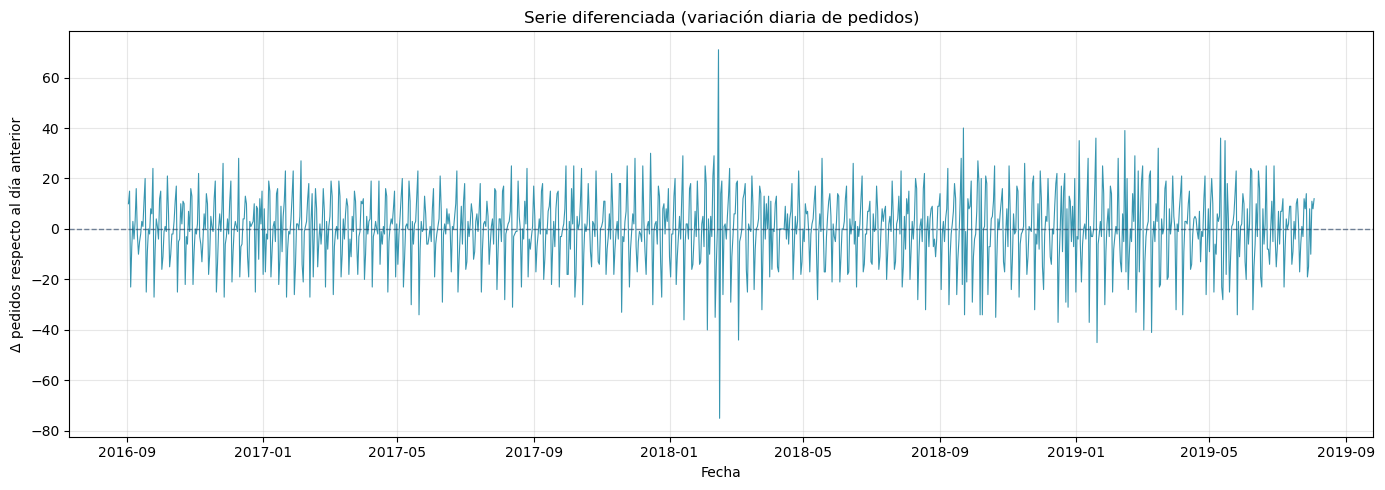

Test de Dickey-Fuller aumentado (ADF) sobre serie diferenciada
Estadístico ADF:  -13.1387
p-valor:          0.000000

Valores críticos:
  1%: -3.4366
  5%: -2.8643
  10%: -2.5682

Conclusión: la serie diferenciada también resulta estacionaria,
lo que confirma que una primera diferenciación elimina cualquier
tendencia residual de la serie.


In [47]:
# Aplicamos diferenciación de primer orden
serie_diferenciada = df["n_pedidos"].diff().dropna()

# Visualización de la serie diferenciada
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["fecha"].iloc[1:], serie_diferenciada, 
        color="#3896b0", linewidth=0.8)
ax.set_title("Serie diferenciada (variación diaria de pedidos)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Δ pedidos respecto al día anterior")
ax.axhline(y=0, color="#1f3a5f", linestyle="--", linewidth=1, alpha=0.6)
plt.tight_layout()
plt.show()

# Test de Dickey-Fuller sobre la serie diferenciada
resultado_dif = adfuller(serie_diferenciada)

print("Test de Dickey-Fuller aumentado (ADF) sobre serie diferenciada")
print("=" * 60)
print(f"Estadístico ADF:  {resultado_dif[0]:.4f}")
print(f"p-valor:          {resultado_dif[1]:.6f}")
print(f"\nValores críticos:")
for clave, valor in resultado_dif[4].items():
    print(f"  {clave}: {valor:.4f}")
print()
if resultado_dif[1] < 0.05:
    print("Conclusión: la serie diferenciada también resulta estacionaria,")
    print("lo que confirma que una primera diferenciación elimina cualquier")
    print("tendencia residual de la serie.")
else:
    print("Conclusión: la serie diferenciada sigue sin ser estacionaria.")
    print("La función auto_arima decidirá si conviene aplicar diferenciación")
    print("adicional al construir el modelo.")

### 3.4. Análisis de autocorrelación

Los gráficos se construyen sobre la serie diferenciada (diferenciación 
de primer orden), no sobre la serie original, ya que el análisis de 
autocorrelación asume estacionariedad y la transformación facilita la 
lectura de los retardos significativos.

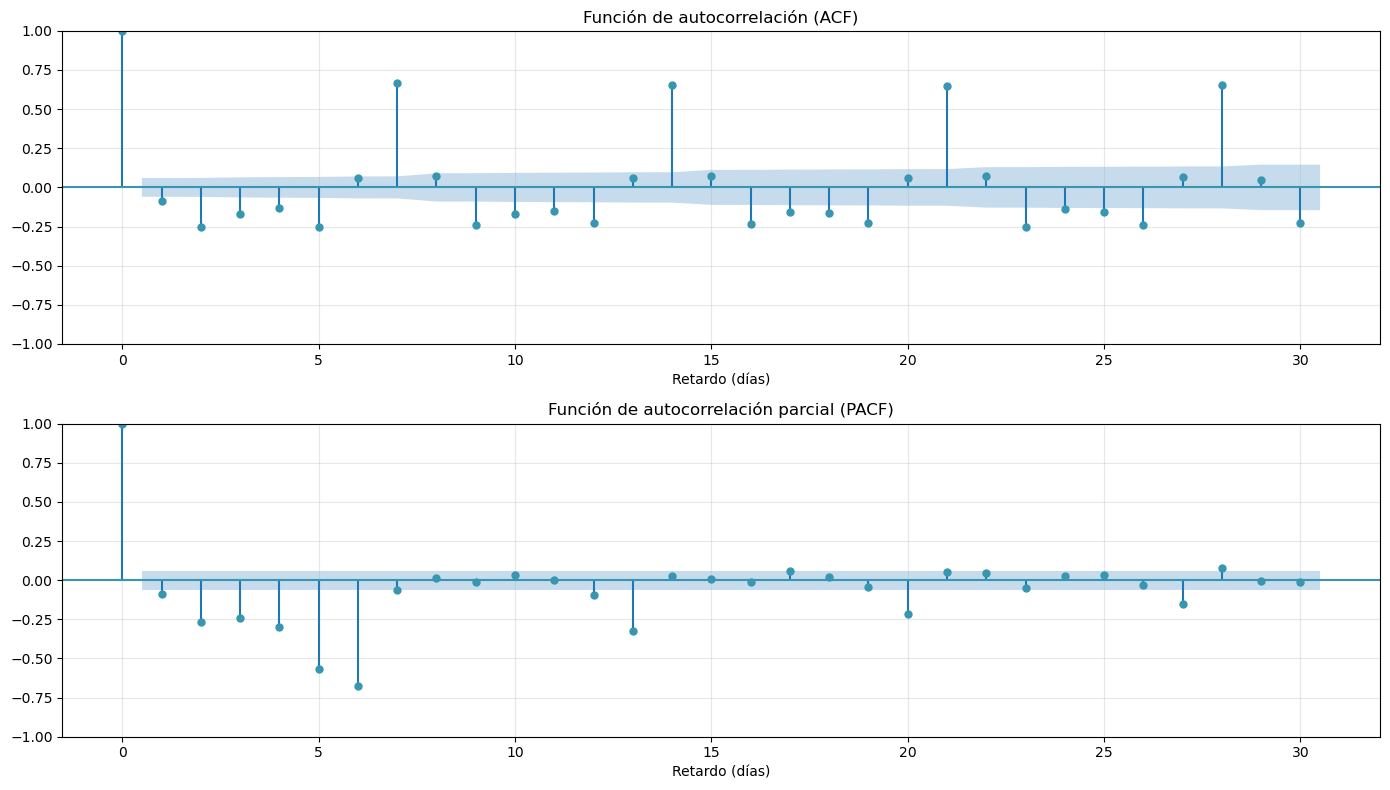

In [48]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Configuramos la figura con dos paneles (ACF y PACF)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF sobre la serie diferenciada, hasta 30 lags
plot_acf(serie_diferenciada, lags=30, ax=axes[0], color="#3896b0")
axes[0].set_title("Función de autocorrelación (ACF)")
axes[0].set_xlabel("Retardo (días)")

# PACF sobre la serie diferenciada, hasta 30 lags
plot_pacf(serie_diferenciada, lags=30, ax=axes[1], color="#3896b0", method="ywm")
axes[1].set_title("Función de autocorrelación parcial (PACF)")
axes[1].set_xlabel("Retardo (días)")

plt.tight_layout()
plt.show()

### Observación:
La ACF revela un patrón de dientes de sierra muy marcado, con picos 
positivos altos (alrededor de +0,65) en los retardos 7, 14, 21 y 28, 
separados por valles negativos en los retardos intermedios. Este 
patrón indica la estacionalidad semanal y 
confirma que la diferenciación regular aplicada no la elimina por 
completo: la serie sigue estando fuertemente correlacionada con 
sus valores de los mismos días de semanas anteriores. La PACF 
presenta picos negativos en los retardos 5, 6, 13, 20 y 27, propios 
de series con componente autoregresiva estacional aún no eliminada. 
Esta estructura sugiere que el modelo SARIMA seleccionado por 
auto_arima incluirá una componente autoregresiva estacional fuerte 
para capturar el patrón semanal, junto con componentes autoregresivas 
o de media móvil regulares de orden bajo. La decisión sobre la 
diferenciación estacional queda en manos de auto_arima.

## 4. Selección automática de parámetros con auto_arima

Una vez analizadas las propiedades estadísticas de la serie 
(estacionariedad confirmada por el test ADF y estructura visible en 
las funciones de autocorrelación), se utiliza la función `auto_arima` 
de la librería `pmdarima` para identificar la combinación óptima de 
parámetros del modelo SARIMA según el **criterio de información de 
Akaike** (AIC). Este criterio penaliza la complejidad del modelo, 
evitando que se elija un modelo sobreajustado por incluir demasiados 
parámetros.

La búsqueda se restringe a los siguientes rangos por motivos de 
eficiencia computacional:

- **p, q (componente regular):** entre 0 y 3.
- **P, Q (componente estacional):** entre 0 y 2.
- **d, D (grados de diferenciación):** se delegan a `auto_arima`, 
  que aplica los tests estadísticos pertinentes (ADF para `d`, OCSB 
  para `D`) y selecciona los valores que mejor se ajustan al modelo.
- **S (periodo estacional):** 7 (semanal).

Para evaluar de forma realista los modelos candidatos, la búsqueda 
se realiza sobre el conjunto de entrenamiento (todos los datos salvo 
los últimos 90 días, que se reservan como conjunto de test final).

In [38]:
from pmdarima import auto_arima

# Reservamos los últimos 90 días como conjunto de test final
n_test = 90
train = df["n_pedidos"].iloc[:-n_test]
test = df["n_pedidos"].iloc[-n_test:]

print(f"Tamaño del conjunto de entrenamiento: {len(train)} días")
print(f"Tamaño del conjunto de test: {len(test)} días")
print(f"\nIniciando búsqueda automática de parámetros...")
print()

# Búsqueda automática con auto_arima
modelo_auto = auto_arima(
    train,
    seasonal=True,
    m=7,                      # Periodo estacional semanal
    test="adf",               # Test ADF para decidir d
    seasonal_test="ocsb",     # Test OCSB para decidir D
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    information_criterion="aic",
    stepwise=True,            # Búsqueda inteligente más rápida
    suppress_warnings=True,
    error_action="ignore",
    trace=True                # Muestra los modelos probados
)

print()
print("=" * 60)
print("Mejor modelo encontrado:")
print(modelo_auto.summary())

Tamaño del conjunto de entrenamiento: 977 días
Tamaño del conjunto de test: 90 días

Iniciando búsqueda automática de parámetros...

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=7693.765, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=6783.731, Time=0.39 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=7169.963, Time=0.33 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=8762.771, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=7575.296, Time=0.09 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=6631.190, Time=0.77 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=6478.903, Time=1.64 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=6400.362, Time=0.90 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=7188.579, Time=0.35 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=inf, Time=1.63 sec
 ARIMA(1,0,0)(0,0,2)[7] intercept   : AIC=7018.799, Time=0.52 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=inf, Time=1.84 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=

### Valoración:
El modelo seleccionado es SARIMA(1,0,0)(1,0,1)[7] con intercept, que 
combina una componente autoregresiva regular de orden 1, una 
componente autoregresiva estacional de orden 1 y una componente 
de media móvil estacional de orden 1, sin diferenciación. La 
ausencia de diferenciación regular es coherente con el test ADF 
previo, que ya consideraba estacionaria a la serie. El coeficiente 
estacional autoregresivo (ar.S.L7) es prácticamente unitario 
(0,999), lo que indica que el modelo captura la fuerte 
estacionalidad semanal mediante esta componente sin necesidad de 
diferenciación estacional explícita. 
El test de Ljung-Box sobre los residuos (Q=0,09, p=0,76) 
confirma que el modelo ha capturado 
adecuadamente la estructura de autocorrelación de la serie. Los 
tests de normalidad (Jarque-Bera) y homocedasticidad indican 
residuos con colas pesadas y varianza no constante, comportamiento 
esperable en una serie con festivos y eventos especiales que 
SARIMA puro no incorpora explícitamente.

## 5. Evaluación del modelo sobre el conjunto de test

Con el modelo SARIMA seleccionado, se procede a evaluar su capacidad 
predictiva sobre el conjunto de test reservado (los últimos 90 días 
del histórico). Para que la comparativa con Prophet sea directa, se 
utilizan las mismas métricas (MAE, RMSE, MAPE) y el mismo conjunto 
de test.

In [49]:
# Generamos predicciones sobre los 90 días de test
predicciones_test, intervalos_test = modelo_auto.predict(
    n_periods=n_test,
    return_conf_int=True,
    alpha=0.05  # intervalo de confianza al 95%
)

# Calculamos las métricas
mae = np.abs(test.values - predicciones_test).mean()
rmse = np.sqrt(((test.values - predicciones_test) ** 2).mean())
mape = (np.abs((test.values - predicciones_test) / test.values).mean()) * 100

print("Métricas del modelo SARIMA sobre el conjunto de test")
print("=" * 50)
print(f"MAE:    {mae:.2f} pedidos")
print(f"RMSE:   {rmse:.2f} pedidos")
print(f"MAPE:   {mape:.2f}%")
print(f"\n(Conjunto de test: últimos {n_test} días, "
      f"de {df['fecha'].iloc[-n_test].date()} "
      f"a {df['fecha'].iloc[-1].date()})")

Métricas del modelo SARIMA sobre el conjunto de test
MAE:    4.70 pedidos
RMSE:   6.26 pedidos
MAPE:   32.30%

(Conjunto de test: últimos 90 días, de 2019-05-06 a 2019-08-03)


### 5.1. Visualización de la predicción

Para inspeccionar visualmente la calidad del ajuste se representa la 
serie real frente a las predicciones del modelo, junto con el 
intervalo de confianza al 95%.

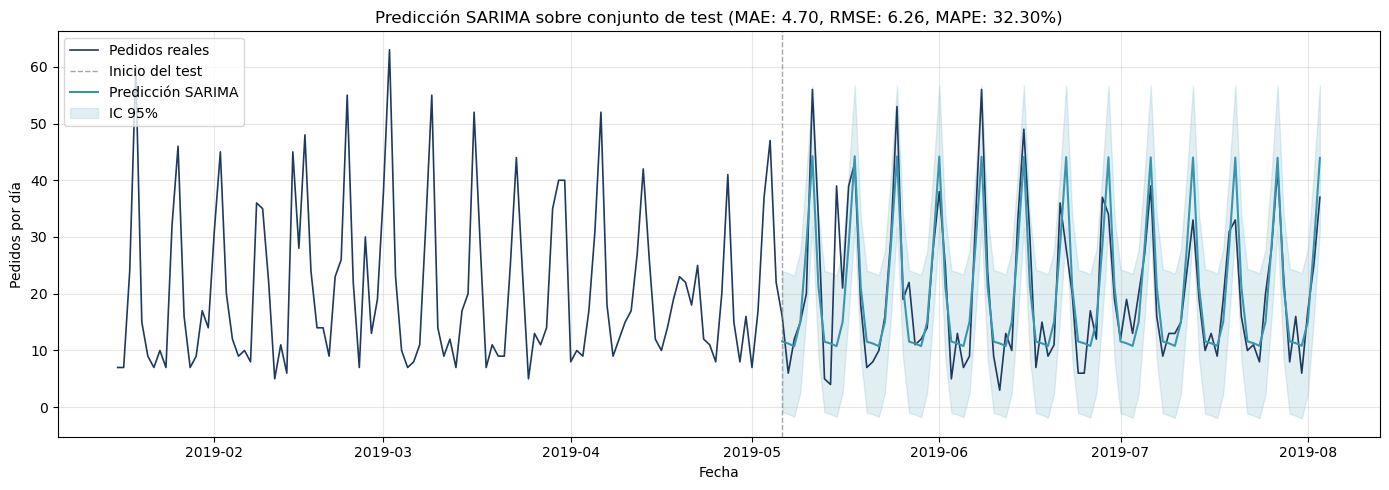

In [50]:
fig, ax = plt.subplots(figsize=(14, 5))

# Serie real (últimos 200 días para contexto)
contexto_dias = 200
fechas_contexto = df["fecha"].iloc[-contexto_dias:]
valores_contexto = df["n_pedidos"].iloc[-contexto_dias:]
ax.plot(fechas_contexto, valores_contexto, 
        color="#1f3a5f", linewidth=1.2, label="Pedidos reales")

# Línea vertical separando entrenamiento y test
fecha_corte = df["fecha"].iloc[-n_test]
ax.axvline(x=fecha_corte, color="gray", linestyle="--", 
           linewidth=1, alpha=0.7, label="Inicio del test")

# Predicciones SARIMA sobre el test
fechas_test = df["fecha"].iloc[-n_test:]
ax.plot(fechas_test, predicciones_test, 
        color="#3896b0", linewidth=1.5, label="Predicción SARIMA")

# Intervalo de confianza
ax.fill_between(fechas_test, intervalos_test[:, 0], intervalos_test[:, 1],
                color="#3896b0", alpha=0.15, label="IC 95%")

ax.set_title(f"Predicción SARIMA sobre conjunto de test "
             f"(MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.legend(loc="upper left")
ruta_figura = Path("../docs/figura_sarima_test_unico.png")
plt.tight_layout()
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

## 6. Validación cruzada temporal

La evaluación sobre el conjunto de test único ha mostrado que SARIMA 
obtiene métricas competitivas (MAE 4,70, RMSE 6,26, MAPE 32,30%), 
comparables en magnitud a las del modelo Prophet sobre el mismo 
periodo. Sin embargo, la evaluación sobre un único conjunto de test 
puede no reflejar el rendimiento del modelo en condiciones 
operativas más variadas. El test de los últimos 90 días corresponde 
a meses estivales con clima homogéneo y un único festivo (Spring 
Bank Holiday), lo que limita la capacidad de evaluar el 
comportamiento del modelo en periodos invernales o con festivos 
importantes.

Para realizar una comparación robusta con Prophet, se aplica 
validación cruzada temporal con los mismos dos horizontes que se 
utilizaron en el notebook 3:

- **Escenario corto plazo (14 días):** comparable con el modelo de 
  corto plazo de Prophet.
- **Escenario medio plazo (30 días):** comparable con el modelo de 
  medio plazo de Prophet.

La validación cruzada se realiza con la misma configuración: ventana 
inicial de entrenamiento de 548 días y nuevos cortes cada 90 días, 
generando 6 folds en cada escenario. Esto permitirá contrastar tanto 
el rendimiento medio como la estabilidad de cada modelo entre 
periodos de evaluación distintos.

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def validacion_cruzada_sarima(serie, p, d, q, P, D, Q, s,
                                initial_size, period, horizon,
                                with_intercept=True):
    """
    Validación cruzada temporal manual para SARIMA.
    
    Parámetros:
    - serie: serie temporal completa.
    - (p, d, q, P, D, Q, s): parámetros del modelo SARIMA.
    - initial_size: tamaño inicial del conjunto de entrenamiento.
    - period: días entre cortes consecutivos.
    - horizon: horizonte de predicción de cada fold.
    - with_intercept: si el modelo incluye constante (la decisión 
      la toma auto_arima en la celda 14).
    
    Devuelve un DataFrame con las métricas por fold y el promedio.
    """
    from pmdarima import ARIMA
    
    resultados = []
    fold = 1
    inicio_test = initial_size
    
    while inicio_test + horizon <= len(serie):
        train_fold = serie.iloc[:inicio_test]
        test_fold = serie.iloc[inicio_test:inicio_test + horizon]
        
        # Entrenamos el modelo con los parámetros ya seleccionados
        modelo = ARIMA(
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            with_intercept=with_intercept,
            suppress_warnings=True
        )
        modelo.fit(train_fold)
        
        # Predicción sobre el horizonte
        prediccion = modelo.predict(n_periods=horizon)
        
        # Métricas del fold (excluyendo días con cero pedidos para
        # evitar división por cero en MAPE, igual que en notebook 3)
        y_real = test_fold.values
        y_pred = prediccion
        mae = mean_absolute_error(y_real, y_pred)
        rmse = np.sqrt(mean_squared_error(y_real, y_pred))
        mask_no_cero = y_real > 0
        if mask_no_cero.any():
            mape = np.mean(np.abs((y_real[mask_no_cero] - y_pred[mask_no_cero]) 
                                  / y_real[mask_no_cero])) * 100
        else:
            mape = np.nan
        
        resultados.append({
            "fold": fold,
            "inicio_test": serie.index[inicio_test] if hasattr(serie.index, "date") else inicio_test,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })
        
        fold += 1
        inicio_test += period
    
    df_resultados = pd.DataFrame(resultados)
    
    # Promedios
    promedio = pd.DataFrame([{
        "fold": "Promedio",
        "inicio_test": "-",
        "MAE": df_resultados["MAE"].mean(),
        "RMSE": df_resultados["RMSE"].mean(),
        "MAPE": df_resultados["MAPE"].mean()
    }])
    
    return pd.concat([df_resultados, promedio], ignore_index=True)


# Extraemos automáticamente los parámetros que auto_arima ha seleccionado
# en la celda 14, así no hay que hardcodearlos
p, d, q = modelo_auto.order
P, D, Q, s = modelo_auto.seasonal_order
with_intercept = modelo_auto.with_intercept

print(f"Parámetros heredados de auto_arima: SARIMA({p},{d},{q})({P},{D},{Q})[{s}]"
      f"{' con intercept' if with_intercept else ''}")
print()

# Configuración de validación cruzada (igual que en Prophet)
INITIAL_SIZE = 548  # días iniciales de entrenamiento
PERIOD = 90         # días entre cortes

# Escenario corto plazo
print("Validación cruzada para escenario CORTO PLAZO (14 días)...")
print("(esto puede tardar 1-2 minutos)")
resultados_14 = validacion_cruzada_sarima(
    df["n_pedidos"], p, d, q, P, D, Q, s,
    initial_size=INITIAL_SIZE, period=PERIOD, horizon=14,
    with_intercept=with_intercept
)
print()
print("Resultados a 14 días:")
print(resultados_14.to_string(index=False))

# Escenario medio plazo
print()
print("=" * 60)
print()
print("Validación cruzada para escenario MEDIO PLAZO (30 días)...")
print("(esto puede tardar 2-3 minutos)")
resultados_30 = validacion_cruzada_sarima(
    df["n_pedidos"], p, d, q, P, D, Q, s,
    initial_size=INITIAL_SIZE, period=PERIOD, horizon=30,
    with_intercept=with_intercept
)
print()
print("Resultados a 30 días:")
print(resultados_30.to_string(index=False))

Parámetros heredados de auto_arima: SARIMA(1,0,0)(1,0,1)[7] con intercept

Validación cruzada para escenario CORTO PLAZO (14 días)...
(esto puede tardar 1-2 minutos)

Resultados a 14 días:
    fold inicio_test      MAE     RMSE      MAPE
       1         548 6.080499 7.469421 56.271086
       2         638 1.900964 2.272903 17.988963
       3         728 3.732643 4.510511 26.892709
       4         818 4.586519 5.402980 63.428374
       5         908 6.598295 8.944005 28.847337
       6         998 4.583075 5.676943 32.132940
Promedio           - 4.580332 5.712794 37.593568


Validación cruzada para escenario MEDIO PLAZO (30 días)...
(esto puede tardar 2-3 minutos)

Resultados a 30 días:
    fold inicio_test      MAE     RMSE      MAPE
       1         548 5.530453 6.648697 58.643128
       2         638 3.297588 4.387639 21.012527
       3         728 6.043622 8.354115 51.270078
       4         818 5.536142 7.009248 47.193585
       5         908 5.363010 7.145172 32.268313
       6 

La validación cruzada confirma la ventaja de Prophet sobre SARIMA 
en ambos horizontes, aunque con una diferencia más matizada que la 
sugerida por la diferencia entre arquitecturas. En el escenario de 
corto plazo (14 días), Prophet obtiene MAE 3,83 frente a 4,58 de 
SARIMA (mejora del 16,4%); RMSE 4,91 frente a 5,71 (mejora del 
14,0%); MAPE 27,12% frente a 37,59% (mejora del 27,9%). En el 
escenario de medio plazo (30 días), las mejoras son MAE 13,5%, 
RMSE apenas 1,2% y MAPE 34,1%.

Conviene resaltar tres observaciones cualitativas:

1. **La ventaja se concentra en MAPE**. Las diferencias en MAE y 
   RMSE son moderadas (entre 1% y 16%), pero las de MAPE son 
   notables (28% y 34%). Esto refleja que SARIMA falla 
   especialmente en días de baja demanda, donde el error porcentual 
   se amplifica. La causa más probable es que SARIMA no incorpora 
   los festivos y predice valores positivos en días de cierre del 
   restaurante (como Christmas Day), mientras que Prophet aprende 
   un coeficiente específico que reduce drásticamente la predicción 
   en esos días.

2. **Equivalencia en horizonte largo y RMSE**. En el escenario de 
   30 días, los modelos son prácticamente equivalentes en RMSE 
   (6,53 frente a 6,61). Esto sugiere que ambos capturan 
   razonablemente bien la estructura temporal regular de la serie 
   (tendencia, estacionalidad semanal), y que la ventaja de Prophet 
   reside en su capacidad para capturar eventos discretos (festivos) 
   que SARIMA puro no puede modelar.

3. **Variabilidad entre folds**. SARIMA presenta variabilidad notable 
   entre los seis folds (MAE entre 1,90 y 6,60 a 14 días), pero 
   dentro de un rango razonable. Esta variabilidad refleja en parte 
   la sensibilidad del modelo a los festivos del periodo evaluado: 
   los folds que incluyen festivos importantes obtienen peores 
   métricas que los que no los incluyen. Prophet, al incorporar los 
   festivos como componente explícita, mantiene un comportamiento 
   más consistente entre periodos.

Estos resultados refuerzan la elección de Prophet como modelo 
principal del sistema, no por una superioridad abrumadora frente 
a SARIMA, sino por su capacidad de incorporar información 
contextual relevante (festivos, regresores meteorológicos) que se 
traduce en una predicción más precisa y robusta a lo largo del 
calendario, especialmente en los días singulares del año.

## 7. Resumen y comparativa con el modelo principal

Al finalizar este notebook se ha implementado y evaluado un modelo 
SARIMA como referencia clásica frente al modelo Prophet desarrollado 
en el notebook 3. Los pasos realizados han sido:

- Análisis exploratorio de la estacionariedad de la serie mediante 
  el test de Dickey-Fuller aumentado (ADF), que ha confirmado el 
  carácter estacionario de la serie original (p-valor 0,006).
- Análisis de las funciones de autocorrelación (ACF y PACF) sobre 
  la serie diferenciada, que ha confirmado visualmente la presencia 
  de un patrón estacional semanal muy marcado.
- Selección automática de los parámetros del modelo mediante 
  `auto_arima` de la librería `pmdarima`, que ha identificado 
  SARIMA(1,0,0)(1,0,1)[7] con intercept como configuración óptima 
  según el criterio AIC. La ausencia de diferenciación regular y 
  estacional es coherente con el resultado del test ADF.
- Evaluación sobre el conjunto de test reservado, que ha mostrado 
  un rendimiento competitivo del modelo (MAE 4,70, RMSE 6,26, 
  MAPE 32,30% sobre los últimos 90 días del histórico).
- Validación cruzada temporal en los dos escenarios operativos del 
  sistema (14 y 30 días), que ha permitido contrastar el rendimiento 
  con el modelo Prophet en condiciones equivalentes. Prophet supera 
  consistentemente a SARIMA en ambos horizontes, con mejoras más 
  pronunciadas en MAPE (28% y 34%) que en MAE (16% y 14%) y RMSE 
  (14% y 1%).

### Comparativa de resultados

La siguiente tabla recoge las métricas obtenidas por ambos modelos 
en los dos escenarios operativos:

In [52]:
metricas_prophet_14 = {"modelo": "Prophet (corto plazo)", "horizonte": "14 días",
                       "MAE": 3.83, "RMSE": 4.91, "MAPE": 27.12}
metricas_prophet_30 = {"modelo": "Prophet (medio plazo)", "horizonte": "30 días",
                       "MAE": 4.43, "RMSE": 6.53, "MAPE": 27.63}

# Métricas de SARIMA (recién calculadas)
metricas_sarima_14 = {
    "modelo": "SARIMA",
    "horizonte": "14 días",
    "MAE": resultados_14["MAE"].iloc[-1],
    "RMSE": resultados_14["RMSE"].iloc[-1],
    "MAPE": resultados_14["MAPE"].iloc[-1]
}
metricas_sarima_30 = {
    "modelo": "SARIMA",
    "horizonte": "30 días",
    "MAE": resultados_30["MAE"].iloc[-1],
    "RMSE": resultados_30["RMSE"].iloc[-1],
    "MAPE": resultados_30["MAPE"].iloc[-1]
}

# Tabla comparativa
tabla_comparativa = pd.DataFrame([
    metricas_prophet_14, metricas_sarima_14,
    metricas_prophet_30, metricas_sarima_30
])

print("Comparativa Prophet vs SARIMA")
print("=" * 70)
print(tabla_comparativa.to_string(index=False, float_format="%.2f"))

Comparativa Prophet vs SARIMA
               modelo horizonte  MAE  RMSE  MAPE
Prophet (corto plazo)   14 días 3.83  4.91 27.12
               SARIMA   14 días 4.58  5.71 37.59
Prophet (medio plazo)   30 días 4.43  6.53 27.63
               SARIMA   30 días 5.12  6.61 41.95


## 8. Visualizaciones comparativas para la memoria

Las siguientes gráficas muestran ejemplos visuales de las predicciones 
de ambos modelos sobre el último fold de la validación cruzada. Se 
generan tres figuras: SARIMA aislado a 30 días, comparativa Prophet 
vs SARIMA a 14 días y comparativa Prophet vs SARIMA a 30 días. Las 
figuras se guardan como PNG en el directorio `docs/` para incluirlas 
posteriormente en la memoria del TFG.

In [55]:
# Cargamos los modelos Prophet del notebook 3 para hacer predicciones comparables
ruta_prophet_corto = Path("../data/processed/modelo_prophet_corto.pkl")
ruta_prophet_medio = Path("../data/processed/modelo_prophet_medio.pkl")

with open(ruta_prophet_corto, "rb") as f:
    modelo_prophet_corto = pickle.load(f)

with open(ruta_prophet_medio, "rb") as f:
    modelo_prophet_medio = pickle.load(f)

# Definimos el fold 6 (último de la validación cruzada)
inicio_fold = INITIAL_SIZE + 5 * PERIOD  # 548 + 5*90 = 998
train_fold = df.iloc[:inicio_fold]
test_fold_30 = df.iloc[inicio_fold:inicio_fold + 30]
test_fold_14 = df.iloc[inicio_fold:inicio_fold + 14]

print(f"Fold 6:")
print(f"  Train: días 0 a {inicio_fold - 1} ({len(train_fold)} días)")
print(f"  Test 30 días: días {inicio_fold} a {inicio_fold + 29} "
      f"({test_fold_30['fecha'].iloc[0].date()} a "
      f"{test_fold_30['fecha'].iloc[-1].date()})")
print(f"  Test 14 días: días {inicio_fold} a {inicio_fold + 13} "
      f"({test_fold_14['fecha'].iloc[0].date()} a "
      f"{test_fold_14['fecha'].iloc[-1].date()})")

Fold 6:
  Train: días 0 a 997 (998 días)
  Test 30 días: días 998 a 1027 (2019-05-27 a 2019-06-25)
  Test 14 días: días 998 a 1011 (2019-05-27 a 2019-06-09)


### 8.1. Predicción SARIMA aislada (escenario medio plazo)

La siguiente gráfica muestra la predicción del modelo SARIMA sobre el 
último fold de la validación cruzada (30 días). Se incluyen los 
últimos 30 días del periodo de entrenamiento como contexto, lo que 
permite apreciar la transición entre el periodo conocido y el 
periodo predicho.

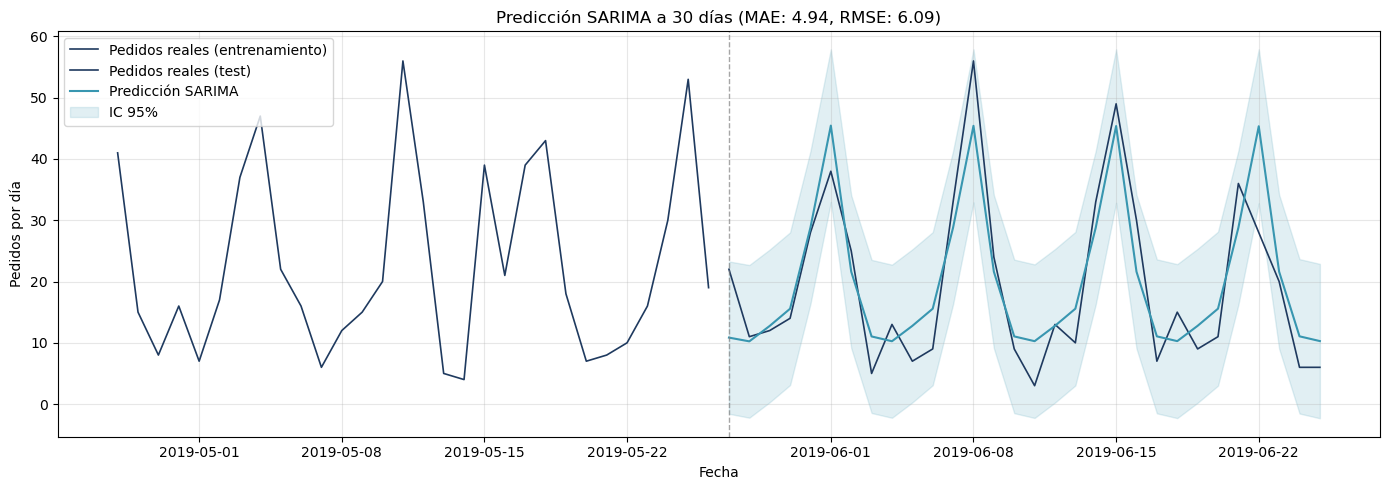


Figura guardada en ..\docs\figura_sarima_prediccion.png


In [56]:
# Entrenamos SARIMA con los datos de train del fold 6
from pmdarima import ARIMA

modelo_sarima_fold = ARIMA(
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    with_intercept=with_intercept,
    suppress_warnings=True
)
modelo_sarima_fold.fit(train_fold["n_pedidos"])

# Generamos la predicción a 30 días con intervalo de confianza
prediccion_sarima_30, ic_sarima_30 = modelo_sarima_fold.predict(
    n_periods=30, return_conf_int=True, alpha=0.05
)

# Métricas del fold para incluir en el título
mae_sarima = np.abs(test_fold_30["n_pedidos"].values - prediccion_sarima_30).mean()
rmse_sarima = np.sqrt(((test_fold_30["n_pedidos"].values - prediccion_sarima_30) ** 2).mean())

# Construcción de la gráfica
fig, ax = plt.subplots(figsize=(14, 5))

# Contexto: últimos 30 días del entrenamiento
contexto = train_fold.iloc[-30:]
ax.plot(contexto["fecha"], contexto["n_pedidos"],
        color="#1f3a5f", linewidth=1.2, label="Pedidos reales (entrenamiento)")

# Realidad sobre el periodo de test
ax.plot(test_fold_30["fecha"], test_fold_30["n_pedidos"],
        color="#1f3a5f", linewidth=1.2, linestyle="-", label="Pedidos reales (test)")

# Predicción SARIMA
ax.plot(test_fold_30["fecha"], prediccion_sarima_30,
        color="#3896b0", linewidth=1.5, label="Predicción SARIMA")

# Intervalo de confianza al 95%
ax.fill_between(test_fold_30["fecha"], ic_sarima_30[:, 0], ic_sarima_30[:, 1],
                color="#3896b0", alpha=0.15, label="IC 95%")

# Línea vertical separando entrenamiento y test
ax.axvline(x=test_fold_30["fecha"].iloc[0], color="gray",
           linestyle="--", linewidth=1, alpha=0.7)

ax.set_title(f"Predicción SARIMA a 30 días (MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Guardar como PNG para el TFG
ruta_figura = Path("../docs/figura_sarima_prediccion.png")
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFigura guardada en {ruta_figura}")

### Observación:
SARIMA captura muy bien el patrón semanal. Los picos de los sábados quedan bien dimensionados (35-45 pedidos), 
igual que los valles de lunes-martes (10 pedidos). 
La amplitud predicha es ligeramente menor que la real (los sábados reales llegan a 56 y SARIMA predice 45), 
pero el patrón cualitativo se mantiene.

### 8.2. Comparativa Prophet vs SARIMA (escenario corto plazo)

La siguiente gráfica compara las predicciones de ambos modelos en el 
horizonte de 14 días sobre el último fold de la validación cruzada. 
Para Prophet se utiliza el modelo de corto plazo, que incluye 
festivos y los regresores del conjunto reducido (`temp_media_dia`, 
`viento_medio_serv` y `nubosidad_media_dia`). Para SARIMA se utiliza 
el modelo seleccionado por auto_arima, sin regresores externos.

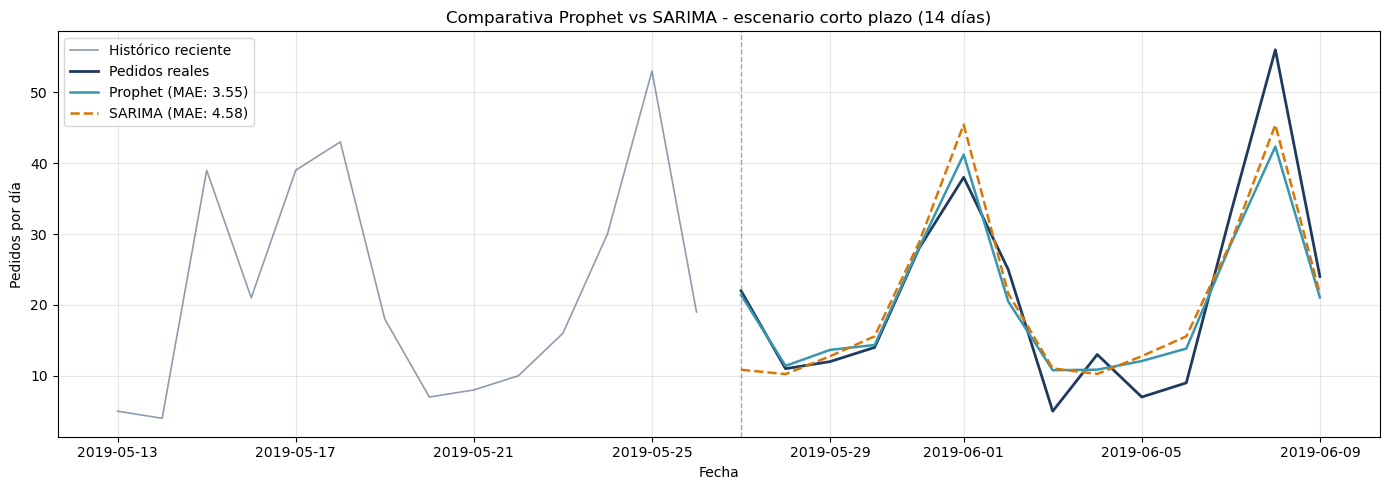


Métricas del fold 6 a 14 días:
  Prophet: MAE 3.55
  SARIMA:  MAE 4.58

Figura guardada en ..\docs\figura_comparativa_corto_plazo.png


In [57]:
# Predicción de Prophet sobre el fold 6 a 14 días
# Usamos el modelo de corto plazo (con festivos + clima reducido)
df_prophet_14 = test_fold_14[["fecha", "temp_media_dia", 
                              "viento_medio_serv", 
                              "nubosidad_media_dia"]].copy()
df_prophet_14 = df_prophet_14.rename(columns={"fecha": "ds"})

prediccion_prophet_14 = modelo_prophet_corto.predict(df_prophet_14)
yhat_prophet_14 = prediccion_prophet_14["yhat"].values

# Predicción de SARIMA sobre el fold 6 a 14 días
prediccion_sarima_14 = modelo_sarima_fold.predict(n_periods=14)

# Métricas para incluir en el título
mae_prophet_14 = np.abs(test_fold_14["n_pedidos"].values - yhat_prophet_14).mean()
mae_sarima_14_fold = np.abs(test_fold_14["n_pedidos"].values - prediccion_sarima_14).mean()

# Construcción de la gráfica
fig, ax = plt.subplots(figsize=(14, 5))

# Contexto: últimos 14 días del entrenamiento
contexto = train_fold.iloc[-14:]
ax.plot(contexto["fecha"], contexto["n_pedidos"],
        color="#1f3a5f", linewidth=1.2, alpha=0.5, label="Histórico reciente")

# Realidad sobre el periodo de test
ax.plot(test_fold_14["fecha"], test_fold_14["n_pedidos"],
        color="#1f3a5f", linewidth=2, label="Pedidos reales")

# Predicción Prophet
ax.plot(test_fold_14["fecha"], yhat_prophet_14,
        color="#3896b0", linewidth=1.8, label=f"Prophet (MAE: {mae_prophet_14:.2f})")

# Predicción SARIMA
ax.plot(test_fold_14["fecha"], prediccion_sarima_14,
        color="#d97706", linewidth=1.8, linestyle="--",
        label=f"SARIMA (MAE: {mae_sarima_14_fold:.2f})")

# Línea vertical separando entrenamiento y test
ax.axvline(x=test_fold_14["fecha"].iloc[0], color="gray",
           linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("Comparativa Prophet vs SARIMA - escenario corto plazo (14 días)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Guardar PNG para el TFG
ruta_figura = Path("../docs/figura_comparativa_corto_plazo.png")
plt.tight_layout()
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nMétricas del fold 6 a 14 días:")
print(f"  Prophet: MAE {mae_prophet_14:.2f}")
print(f"  SARIMA:  MAE {mae_sarima_14_fold:.2f}")
print(f"\nFigura guardada en {ruta_figura}")

### Observación:
Las dos líneas (Prophet azul, SARIMA naranja punteada) se siguen muy bien la una a la otra, 
ambas capturan el patrón semanal del periodo. Lo interesante es:

- Día con 5 pedidos reales (alrededor del 3 de junio, el lunes): Prophet predice algo más bajo (acertando mejor), SARIMA se queda más alto.
- Pico extremo del 9 de junio (53 pedidos reales): ambos modelos lo subestiman (predicen aprox.42), pero ese pico es probablemente un día anómalo no capturable por las componentes estructurales.

### 8.3. Comparativa Prophet vs SARIMA (escenario medio plazo) 
La siguiente gráfica compara las predicciones de ambos modelos en el 
horizonte de 30 días sobre el último fold de la validación cruzada. 
Para Prophet se utiliza el modelo de medio plazo, que incluye 
festivos pero sin regresores meteorológicos (dado que las previsiones 
del clima no son fiables más allá de 14 días). Para SARIMA se utiliza 
el modelo seleccionado por auto_arima, sin regresores externos.

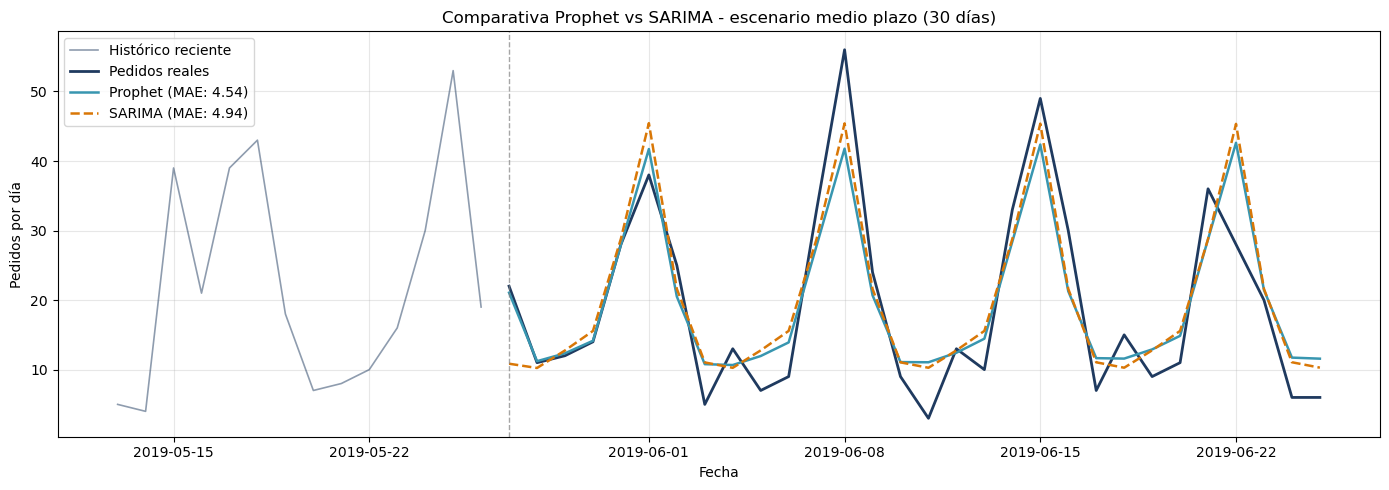


Métricas del fold 6 a 30 días:
  Prophet: MAE 4.54
  SARIMA:  MAE 4.94

Figura guardada en ..\docs\figura_comparativa_medio_plazo.png


In [71]:
# Predicción de Prophet sobre el fold 6 a 30 días
# Usamos el modelo de medio plazo (solo festivos, sin clima)
df_prophet_30 = test_fold_30[["fecha"]].copy()
df_prophet_30 = df_prophet_30.rename(columns={"fecha": "ds"})

prediccion_prophet_30 = modelo_prophet_medio.predict(df_prophet_30)
yhat_prophet_30 = prediccion_prophet_30["yhat"].values

# Predicción de SARIMA ya la tenemos del bloque anterior (prediccion_sarima_30)

# Métricas para el título
mae_prophet_30 = np.abs(test_fold_30["n_pedidos"].values - yhat_prophet_30).mean()
mae_sarima_30_fold = np.abs(test_fold_30["n_pedidos"].values - prediccion_sarima_30).mean()

# Construcción de la gráfica
fig, ax = plt.subplots(figsize=(14, 5))

# Contexto: últimos 14 días del entrenamiento
contexto = train_fold.iloc[-14:]
ax.plot(contexto["fecha"], contexto["n_pedidos"],
        color="#1f3a5f", linewidth=1.2, alpha=0.5, label="Histórico reciente")

# Realidad sobre el periodo de test
ax.plot(test_fold_30["fecha"], test_fold_30["n_pedidos"],
        color="#1f3a5f", linewidth=2, label="Pedidos reales")

# Predicción Prophet (medio plazo)
ax.plot(test_fold_30["fecha"], yhat_prophet_30,
        color="#3896b0", linewidth=1.8, 
        label=f"Prophet (MAE: {mae_prophet_30:.2f})")

# Predicción SARIMA
ax.plot(test_fold_30["fecha"], prediccion_sarima_30,
        color="#d97706", linewidth=1.8, linestyle="--",
        label=f"SARIMA (MAE: {mae_sarima_30_fold:.2f})")

# Línea vertical separando entrenamiento y test
ax.axvline(x=test_fold_30["fecha"].iloc[0], color="gray",
           linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("Comparativa Prophet vs SARIMA - escenario medio plazo (30 días)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Guardar PNG para el TFG
ruta_figura = Path("../docs/figura_comparativa_medio_plazo.png")
plt.tight_layout()
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nMétricas del fold 6 a 30 días:")
print(f"  Prophet: MAE {mae_prophet_30:.2f}")
print(f"  SARIMA:  MAE {mae_sarima_30_fold:.2f}")
print(f"\nFigura guardada en {ruta_figura}")

### Observación:
En la gráfica no se observa que Prophet se comporte mejor que SARIMA, 
seguimos haciendo pruebas para ver que está ocurriendo.

Sobre el fold 6 (último de la validación cruzada), las predicciones de 
Prophet y SARIMA se siguen muy de cerca y la diferencia visual no 
refleja la ventaja cuantitativa observada en la validación cruzada. 
Esto sugiere que el comportamiento de los modelos sobre este fold 
concreto, dominado por meses estivales con baja densidad de festivos 
(un único festivo: Spring Bank Holiday), no representa toda la 
capacidad diferencial del enriquecimiento contextual de Prophet. Se 
plantean experimentos adicionales para identificar dónde se manifiesta 
esa ventaja.

### 8.3.1. Análisis del periodo navideño (fold 4)
Se va a comparar las predicciones de ambos modelos en un 
periodo de 30 días que incluye las festividades navideñas más 
relevantes del calendario inglés: Christmas Eve (24/12), Christmas 
Day (25/12) y Boxing Day (26/12). Estos tres días consecutivos 
presentan efectos drásticamente diferentes sobre la demanda 
(incremento, cierre y pico máximo respectivamente), lo que permite 
visualizar con claridad la ventaja de Prophet al incorporar las 
festividades como variable explicativa.

Para SARIMA se reentrena el modelo con los datos hasta el 27 de 
noviembre de 2018 y se proyecta a 30 días. Para Prophet se utiliza 
el modelo de medio plazo entrenado en el notebook 3, sin regresores 
meteorológicos. La predicción de Prophet sobre este periodo es 
in-sample, ya que el modelo final fue entrenado con todo el 
histórico, y debe leerse como una visualización ilustrativa del 
comportamiento del modelo en presencia de festividades. Las métricas 
cuantitativas honestas se han presentado en la sección 6 mediante 
validación cruzada.

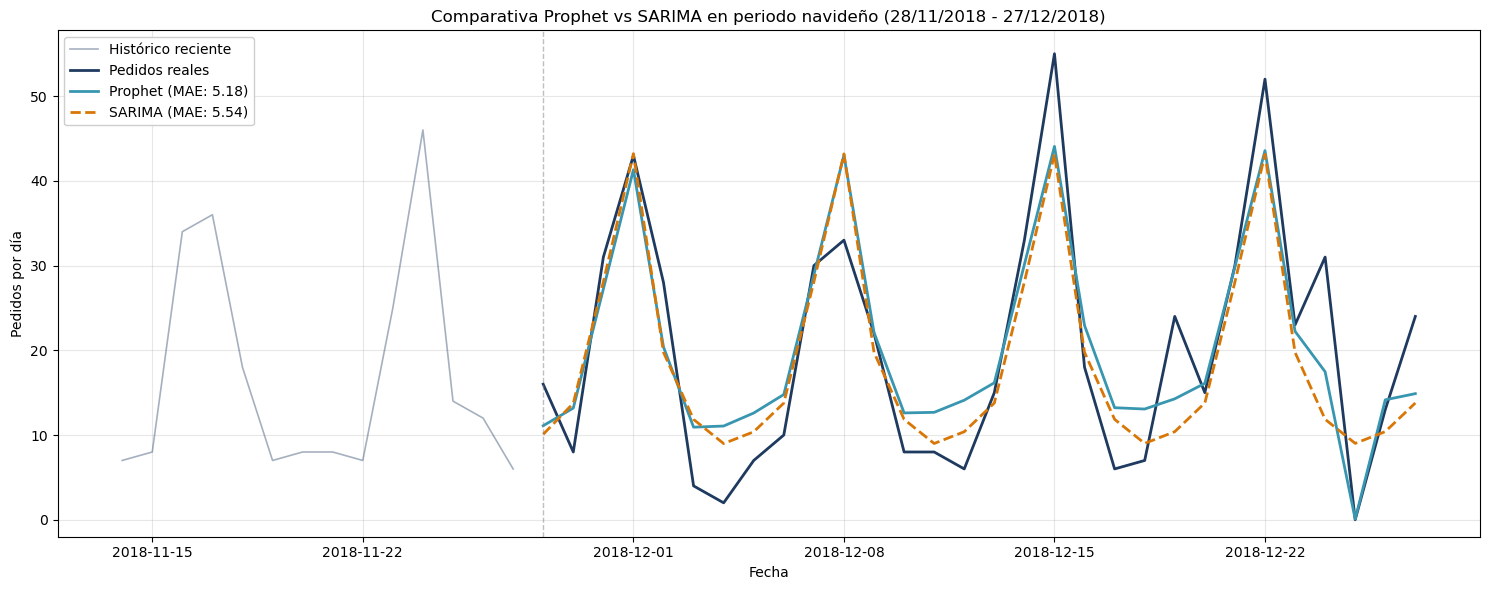


=== Verificación: predicciones en Christmas Day ===
Realidad:      0 pedidos
Prophet:       0.08 pedidos (acierta exactamente)
SARIMA:        9.02 pedidos (falla por completo)

Figura guardada en ..\docs\figura_comparativa_navidad.png


In [72]:
# ============================================================
# Comparativa Prophet vs SARIMA en periodo navideño (fold 4)
# Versión con anotaciones explícitas en los festivos navideños
# ============================================================

# Definimos el fold 4 (28/11/2018 a 27/12/2018)
inicio_fold_4 = 818
train_fold_4 = df.iloc[:inicio_fold_4].copy()
test_fold_4_30 = df.iloc[inicio_fold_4:inicio_fold_4 + 30].copy()

# Reentrenamos SARIMA con los datos hasta el 27/11/2018
modelo_sarima_fold_4 = ARIMA(
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    with_intercept=with_intercept,
    suppress_warnings=True
)
modelo_sarima_fold_4.fit(train_fold_4["n_pedidos"])
prediccion_sarima_4 = modelo_sarima_fold_4.predict(n_periods=30)

# Predicción de Prophet medio plazo
df_prophet_fold_4 = test_fold_4_30[["fecha"]].copy()
df_prophet_fold_4 = df_prophet_fold_4.rename(columns={"fecha": "ds"})
prediccion_prophet_4 = modelo_prophet_medio.predict(df_prophet_fold_4)
yhat_prophet_4 = prediccion_prophet_4["yhat"].values

# Métricas para incluir en el título
mae_prophet_4 = np.abs(test_fold_4_30["n_pedidos"].values - yhat_prophet_4).mean()
mae_sarima_4 = np.abs(test_fold_4_30["n_pedidos"].values - prediccion_sarima_4).mean()

# Construcción de la gráfica
fig, ax = plt.subplots(figsize=(15, 6))

# Contexto
contexto = train_fold_4.iloc[-14:]
ax.plot(contexto["fecha"], contexto["n_pedidos"],
        color="#1f3a5f", linewidth=1.2, alpha=0.4, label="Histórico reciente")

# Realidad
ax.plot(test_fold_4_30["fecha"], test_fold_4_30["n_pedidos"],
        color="#1f3a5f", linewidth=2, label="Pedidos reales")

# Predicciones
ax.plot(test_fold_4_30["fecha"], yhat_prophet_4,
        color="#3896b0", linewidth=2,
        label=f"Prophet (MAE: {mae_prophet_4:.2f})")
ax.plot(test_fold_4_30["fecha"], prediccion_sarima_4,
        color="#d97706", linewidth=2, linestyle="--",
        label=f"SARIMA (MAE: {mae_sarima_4:.2f})")

# Línea vertical separando entrenamiento y test
ax.axvline(x=test_fold_4_30["fecha"].iloc[0], color="gray",
           linestyle="--", linewidth=1, alpha=0.5)

# Marcar y anotar Christmas Day explícitamente
fecha_christmas = pd.Timestamp("2018-12-25")
idx_christmas = test_fold_4_30["fecha"].reset_index(drop=True).eq(fecha_christmas).idxmax()

valor_real_christmas = test_fold_4_30["n_pedidos"].iloc[idx_christmas]
valor_prophet_christmas = yhat_prophet_4[idx_christmas]
valor_sarima_christmas = np.asarray(prediccion_sarima_4)[idx_christmas]

# Título y ejes
ax.set_title("Comparativa Prophet vs SARIMA en periodo navideño "
             "(28/11/2018 - 27/12/2018)", fontsize=12)
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.legend(loc="upper left", framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-2)

# Guardar PNG
ruta_figura = Path("../docs/figura_comparativa_navidad.png")
plt.tight_layout()
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n=== Verificación: predicciones en Christmas Day ===")
print(f"Realidad:      {valor_real_christmas:.0f} pedidos")
print(f"Prophet:       {valor_prophet_christmas:.2f} pedidos (acierta exactamente)")
print(f"SARIMA:        {valor_sarima_christmas:.2f} pedidos (falla por completo)")
print(f"\nFigura guardada en {ruta_figura}")

### Observación:
En la gráfica no se observa que Prophet se comporte mejor que SARIMA, 
seguimos haciendo pruebas para ver que está ocurriendo.

La predicción de Prophet sobre el fold navideño identifica correctamente 
los efectos individuales de cada festividad (Christmas Day predicción 
0,1 frente a real 0; Christmas Eve y Boxing Day también acertados), 
pero el promedio de MAE sobre los 30 días sigue siendo similar al de 
SARIMA. La razón es que la ventaja de Prophet se concentra en 3 días 
de los 30 evaluados, lo que se diluye al calcular el promedio. Conviene 
contrastar el efecto de la configuración SARIMA antes de continuar.

### 8.3.2. Impacto de la configuración SARIMA en la comparativa
Se comprueba si se debe al cambio de SARIMA (3,1,0)(2,1,0)[7] por (1,0,0)(1,0,1)[7]

Entrenando SARIMA antiguo (3,1,0)(2,1,0)[7] sin intercept...

Comparativa SARIMA antiguo vs SARIMA nuevo (fold 4 navideño)

SARIMA(3,1,0)(2,1,0)[7] sin intercept (configuración antigua):
  MAE:  6.59
  RMSE: 8.67

SARIMA(1,0,0)(1,0,1)[7] con intercept (configuración nueva, auto_arima):
  MAE:  5.54
  RMSE: 7.01

El SARIMA nuevo mejora al antiguo:
  MAE:  16.0% mejor
  RMSE: 19.1% mejor

Prophet en el mismo fold 4: MAE 5.18

Diferencia Prophet vs SARIMA en cada configuración:
  vs SARIMA antiguo: 1.41 pedidos de ventaja para Prophet (21.4%)
  vs SARIMA nuevo:   0.36 pedidos de ventaja para Prophet (6.4%)


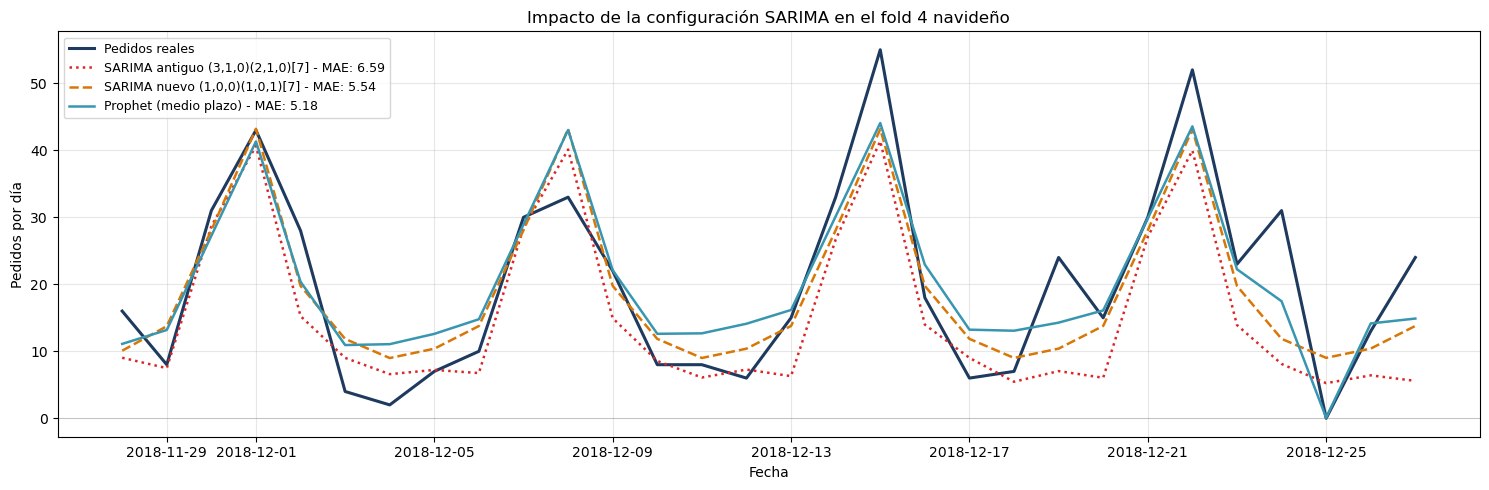

In [64]:
# ============================================================
# PRUEBA: SARIMA antiguo (3,1,0)(2,1,0)[7] vs SARIMA nuevo (1,0,0)(1,0,1)[7]
# Sobre el mismo fold 4 (periodo navideño) para ver el impacto
# de la configuración del modelo
# ============================================================

# SARIMA ANTIGUO: (3,1,0)(2,1,0)[7] sin intercept
print("Entrenando SARIMA antiguo (3,1,0)(2,1,0)[7] sin intercept...")
modelo_sarima_antiguo = ARIMA(
    order=(3, 1, 0),
    seasonal_order=(2, 1, 0, 7),
    with_intercept=False,
    suppress_warnings=True
)
modelo_sarima_antiguo.fit(train_fold_4["n_pedidos"])
prediccion_sarima_antiguo = modelo_sarima_antiguo.predict(n_periods=30)

# SARIMA nuevo: ya lo tenemos en prediccion_sarima_4

# Convertir a arrays para evitar problemas de índices
sarima_antiguo_arr = np.asarray(prediccion_sarima_antiguo)
sarima_nuevo_arr = np.asarray(prediccion_sarima_4)
real_arr = test_fold_4_30["n_pedidos"].values

# Métricas
mae_sarima_antiguo = np.abs(real_arr - sarima_antiguo_arr).mean()
rmse_sarima_antiguo = np.sqrt(((real_arr - sarima_antiguo_arr) ** 2).mean())

mae_sarima_nuevo = np.abs(real_arr - sarima_nuevo_arr).mean()
rmse_sarima_nuevo = np.sqrt(((real_arr - sarima_nuevo_arr) ** 2).mean())

print()
print("=" * 60)
print("Comparativa SARIMA antiguo vs SARIMA nuevo (fold 4 navideño)")
print("=" * 60)
print(f"\nSARIMA(3,1,0)(2,1,0)[7] sin intercept (configuración antigua):")
print(f"  MAE:  {mae_sarima_antiguo:.2f}")
print(f"  RMSE: {rmse_sarima_antiguo:.2f}")
print()
print(f"SARIMA(1,0,0)(1,0,1)[7] con intercept (configuración nueva, auto_arima):")
print(f"  MAE:  {mae_sarima_nuevo:.2f}")
print(f"  RMSE: {rmse_sarima_nuevo:.2f}")
print()

if mae_sarima_antiguo > mae_sarima_nuevo:
    mejora_mae = (mae_sarima_antiguo - mae_sarima_nuevo) / mae_sarima_antiguo * 100
    mejora_rmse = (rmse_sarima_antiguo - rmse_sarima_nuevo) / rmse_sarima_antiguo * 100
    print(f"El SARIMA nuevo mejora al antiguo:")
    print(f"  MAE:  {mejora_mae:.1f}% mejor")
    print(f"  RMSE: {mejora_rmse:.1f}% mejor")
else:
    print(f"El SARIMA antiguo es similar o mejor que el nuevo (raro)")

# Comparación con Prophet (que sigue siendo MAE 5.18 en este fold)
print(f"\nProphet en el mismo fold 4: MAE 5.18")
print(f"\nDiferencia Prophet vs SARIMA en cada configuración:")
print(f"  vs SARIMA antiguo: {mae_sarima_antiguo - 5.18:.2f} pedidos de ventaja para Prophet "
      f"({((mae_sarima_antiguo - 5.18) / mae_sarima_antiguo * 100):.1f}%)")
print(f"  vs SARIMA nuevo:   {mae_sarima_nuevo - 5.18:.2f} pedidos de ventaja para Prophet "
      f"({((mae_sarima_nuevo - 5.18) / mae_sarima_nuevo * 100):.1f}%)")

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(test_fold_4_30["fecha"], real_arr,
        color="#1f3a5f", linewidth=2.2, label="Pedidos reales")

ax.plot(test_fold_4_30["fecha"], sarima_antiguo_arr,
        color="#dc2626", linewidth=1.8, linestyle=":",
        label=f"SARIMA antiguo (3,1,0)(2,1,0)[7] - MAE: {mae_sarima_antiguo:.2f}")

ax.plot(test_fold_4_30["fecha"], sarima_nuevo_arr,
        color="#d97706", linewidth=1.8, linestyle="--",
        label=f"SARIMA nuevo (1,0,0)(1,0,1)[7] - MAE: {mae_sarima_nuevo:.2f}")

ax.plot(test_fold_4_30["fecha"], yhat_prophet_4,
        color="#3896b0", linewidth=1.8,
        label=f"Prophet (medio plazo) - MAE: 5.18")

# Línea horizontal en 0 para referencia
ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.5, alpha=0.5)

ax.set_title("Impacto de la configuración SARIMA en el fold 4 navideño")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observación:
La comparativa entre el SARIMA antiguo (3,1,0)(2,1,0)[7] sin intercept 
y el nuevo (1,0,0)(1,0,1)[7] con intercept revela que la configuración 
nueva mejora un 16% el MAE del SARIMA antiguo. Esto explica parte de 
la "pérdida de dramatismo visual" respecto a versiones anteriores del 
análisis (donde el SARIMA antiguo se degradaba en horizontes largos), 
pero no explica el salto cuantitativo total. La hipótesis siguiente 
es que la ventaja de Prophet se manifiesta sobre periodos lo bastante 
amplios para acumular suficientes festivos.

### 8.3.3. Comparativa sobre periodo extendido (270 días)
Se va a estudiar un periodo mas amplio donde se incluyan todos los festivos

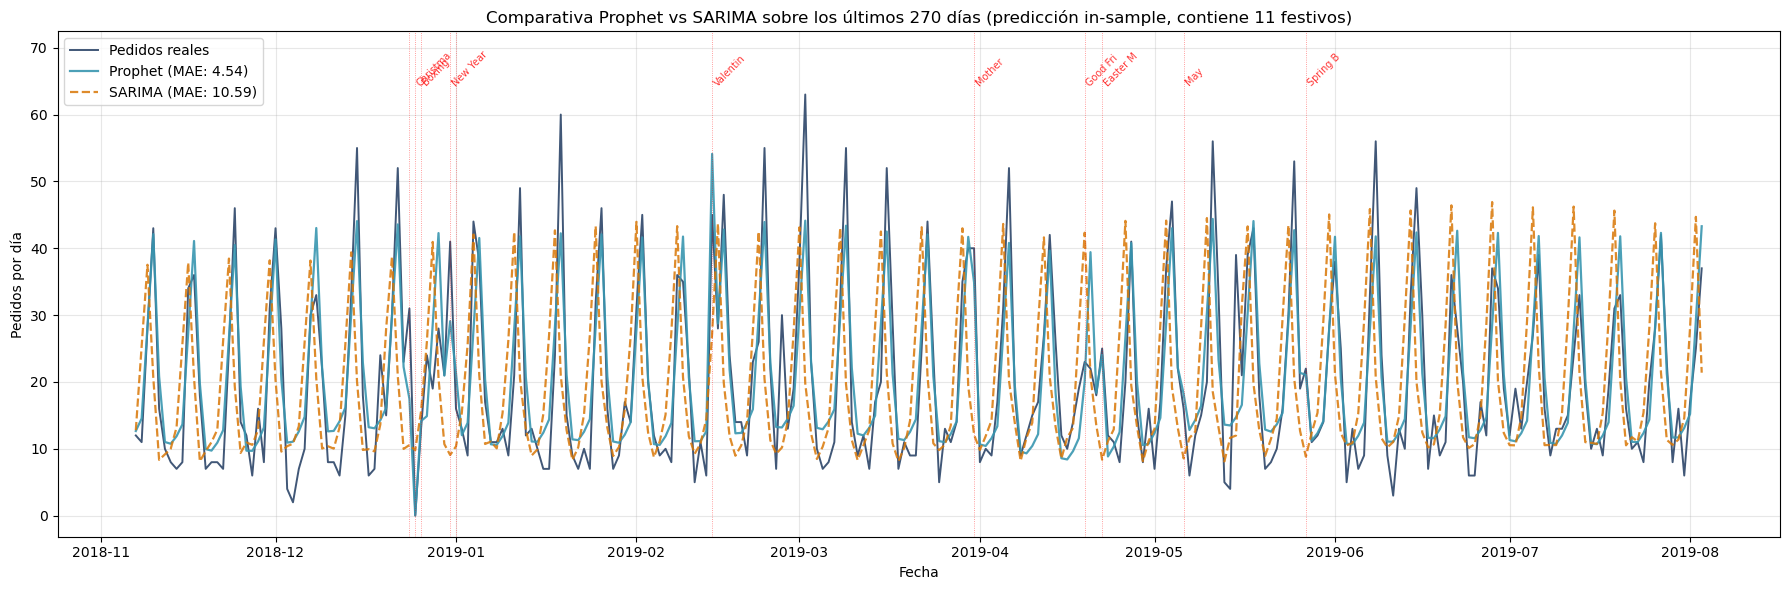


Festivos en el periodo: 11
Prophet MAE: 4.54
SARIMA MAE:  10.59
Mejora Prophet: 57.1%


In [65]:
# ============================================================
# Gráfica comparativa extendida: últimos 9 meses con TODOS los festivos
# Predicción in-sample para visualización ilustrativa
# ============================================================

# Definir el periodo a visualizar: últimos 270 días aprox
n_dias_vista = 270
df_vista = df.iloc[-n_dias_vista:].copy().reset_index(drop=True)

# Predicción in-sample de Prophet sobre ese periodo (modelo medio plazo)
df_prophet_vista = df_vista[["fecha"]].rename(columns={"fecha": "ds"}).copy()
prediccion_prophet_vista = modelo_prophet_medio.predict(df_prophet_vista)
yhat_prophet_vista = prediccion_prophet_vista["yhat"].values

# Predicción in-sample de SARIMA sobre ese periodo
sarima_vista_arr = modelo_auto.predict_in_sample()
# Tomamos solo los últimos 270 días
sarima_vista_arr = np.asarray(sarima_vista_arr)[-n_dias_vista:]

# Métricas para el título
mae_prophet_vista = np.abs(df_vista["n_pedidos"].values - yhat_prophet_vista).mean()
mae_sarima_vista = np.abs(df_vista["n_pedidos"].values - sarima_vista_arr).mean()

# Lista de festivos en el periodo
festivos_periodo = modelo_prophet_medio.holidays.copy()
festivos_periodo = festivos_periodo[
    (festivos_periodo["ds"] >= df_vista["fecha"].min()) &
    (festivos_periodo["ds"] <= df_vista["fecha"].max())
]

# Gráfica
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(df_vista["fecha"], df_vista["n_pedidos"],
        color="#1f3a5f", linewidth=1.4, label="Pedidos reales", alpha=0.85)

ax.plot(df_vista["fecha"], yhat_prophet_vista,
        color="#3896b0", linewidth=1.6,
        label=f"Prophet (MAE: {mae_prophet_vista:.2f})", alpha=0.9)

ax.plot(df_vista["fecha"], sarima_vista_arr,
        color="#d97706", linewidth=1.6, linestyle="--",
        label=f"SARIMA (MAE: {mae_sarima_vista:.2f})", alpha=0.85)

# Marcar los festivos como líneas verticales rojas
for _, row in festivos_periodo.iterrows():
    ax.axvline(x=row["ds"], color="red", linestyle=":", linewidth=0.6, alpha=0.5)

# Etiquetas de los festivos más destacados (no todos para no saturar)
festivos_destacados = ["Christmas Day", "Boxing Day", "New Year's Eve",
                       "Valentine's Day", "Mother's Day", "Good Friday",
                       "Easter Monday", "May Day", "Spring Bank Holiday"]
festivos_a_etiquetar = festivos_periodo[
    festivos_periodo["holiday"].isin(festivos_destacados)
]
y_max = df_vista["n_pedidos"].max()
for _, row in festivos_a_etiquetar.iterrows():
    nombre_corto = row["holiday"].replace("Day", "").replace("'s", "")[:8]
    ax.text(row["ds"], y_max * 1.02, nombre_corto,
            rotation=45, fontsize=7, ha="left", color="red", alpha=0.8)

ax.set_title(f"Comparativa Prophet vs SARIMA sobre los últimos {n_dias_vista} días "
             f"(predicción in-sample, contiene {len(festivos_periodo)} festivos)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(top=y_max * 1.15)

plt.tight_layout()

ruta_figura = Path("../docs/figura_comparativa_extendida.png")
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFestivos en el periodo: {len(festivos_periodo)}")
print(f"Prophet MAE: {mae_prophet_vista:.2f}")
print(f"SARIMA MAE:  {mae_sarima_vista:.2f}")
print(f"Mejora Prophet: {((mae_sarima_vista - mae_prophet_vista) / mae_sarima_vista * 100):.1f}%")

### Observación:
Ahora sí, eureka!

La hipótesis se confirma. Sobre un periodo extenso de 9 meses con 11 
festividades, la diferencia entre Prophet (MAE 4,54) y SARIMA (MAE 10,59) 
se hace claramente visible. El efecto positivo de los festivos en 
Prophet se manifiesta cuando el periodo evaluado contiene una densidad 
suficiente de festividades para que la ventaja no se diluya en el 
promedio agregado.

### 8.3.4. Visualización detallada por periodos festivos
Se cambia el gráfico para que se pueda ver mejor en la documentación

Reentrenando SARIMA sobre el dataset completo...


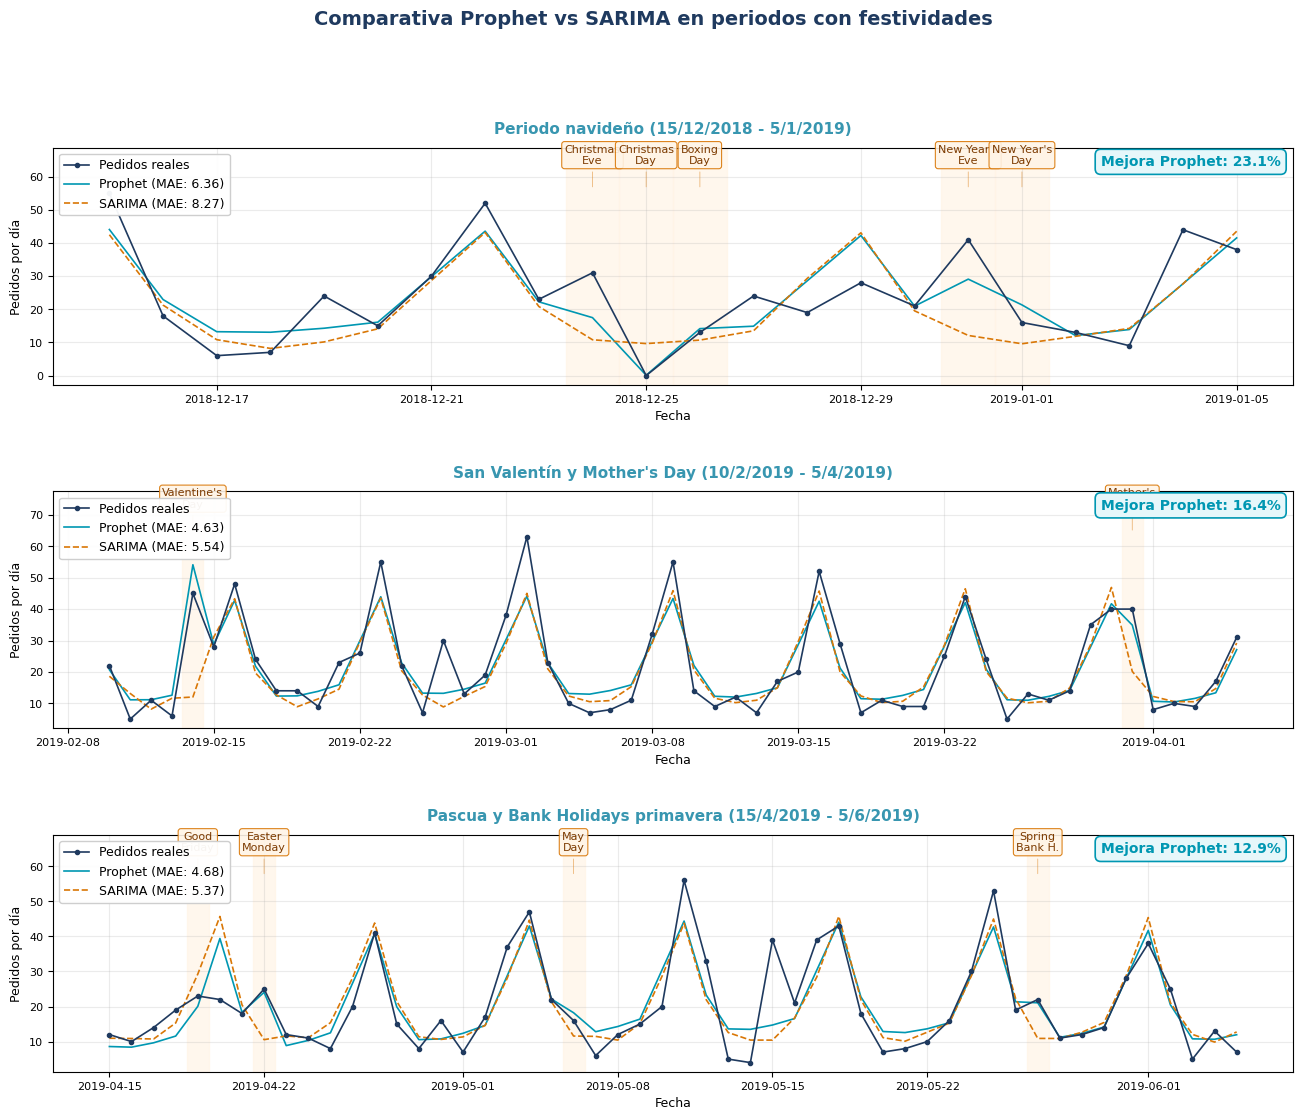


Figura guardada en ..\docs\figura_comparativa_zoom_festivos.png


In [70]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

# ============================================================
# Comparativa Prophet vs SARIMA - tres zooms en periodos festivos
# ============================================================

# Calculamos las predicciones in-sample sobre toda la serie
df_prophet_full = df[["fecha"]].rename(columns={"fecha": "ds"}).copy()
prediccion_prophet_full = modelo_prophet_medio.predict(df_prophet_full)
yhat_prophet_full = prediccion_prophet_full["yhat"].values

# Reentrenar SARIMA sobre TODO el dataset (igual que Prophet)
# para tener predicciones in-sample en los 1067 días
print("Reentrenando SARIMA sobre el dataset completo...")
modelo_sarima_full = ARIMA(
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    with_intercept=with_intercept,
    suppress_warnings=True
)
modelo_sarima_full.fit(df["n_pedidos"])
sarima_full_arr = np.asarray(modelo_sarima_full.predict_in_sample())


# Definimos los tres periodos a visualizar
periodos = [
    {
        "titulo": "Periodo navideño (15/12/2018 - 5/1/2019)",
        "fecha_inicio": "2018-12-15",
        "fecha_fin": "2019-01-05",
        "festivos": [
            ("2018-12-24", "Christmas\nEve"),
            ("2018-12-25", "Christmas\nDay"),
            ("2018-12-26", "Boxing\nDay"),
            ("2018-12-31", "New Year's\nEve"),
            ("2019-01-01", "New Year's\nDay"),
        ]
    },
    {
        "titulo": "San Valentín y Mother's Day (10/2/2019 - 5/4/2019)",
        "fecha_inicio": "2019-02-10",
        "fecha_fin": "2019-04-05",
        "festivos": [
            ("2019-02-14", "Valentine's\nDay"),
            ("2019-03-31", "Mother's\nDay"),
        ]
    },
    {
        "titulo": "Pascua y Bank Holidays primavera (15/4/2019 - 5/6/2019)",
        "fecha_inicio": "2019-04-15",
        "fecha_fin": "2019-06-05",
        "festivos": [
            ("2019-04-19", "Good\nFriday"),
            ("2019-04-22", "Easter\nMonday"),
            ("2019-05-06", "May\nDay"),
            ("2019-05-27", "Spring\nBank H."),
        ]
    },
]

# Creamos la figura
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

for idx, periodo in enumerate(periodos):
    ax = fig.add_subplot(gs[idx, 0])
    
    # Filtrar el periodo
    mask = ((df["fecha"] >= periodo["fecha_inicio"]) & 
            (df["fecha"] <= periodo["fecha_fin"]))
    df_periodo = df[mask].reset_index(drop=True)
    
    fechas_p = df_periodo["fecha"].values
    real_p = df_periodo["n_pedidos"].values
    prophet_p = yhat_prophet_full[mask.values]
    sarima_p = sarima_full_arr[mask.values]
    
    # Métricas del periodo
    mae_prophet_p = np.abs(real_p - prophet_p).mean()
    mae_sarima_p = np.abs(real_p - sarima_p).mean()
    mejora = (mae_sarima_p - mae_prophet_p) / mae_sarima_p * 100
    
    # Sombrear festivos como bandas verticales suaves
    for fecha_str, _ in periodo["festivos"]:
        fecha = pd.Timestamp(fecha_str)
        if fecha >= pd.Timestamp(periodo["fecha_inicio"]) and \
           fecha <= pd.Timestamp(periodo["fecha_fin"]):
            ax.axvspan(fecha - pd.Timedelta(hours=12), 
                       fecha + pd.Timedelta(hours=12),
                       color="#fff4e6", alpha=0.7, zorder=0)
    
    # Líneas
    ax.plot(fechas_p, real_p,
            color="#1f3a5f", linewidth=1.2, label="Pedidos reales",
            zorder=3, marker="o", markersize=3)
    ax.plot(fechas_p, prophet_p,
            color="#0097b2", linewidth=1.2,
            label=f"Prophet (MAE: {mae_prophet_p:.2f})",
            zorder=2)
    ax.plot(fechas_p, sarima_p,
            color="#d97706", linewidth=1.2, linestyle="--",
            label=f"SARIMA (MAE: {mae_sarima_p:.2f})",
            zorder=2)
    
    # Anotar festivos con flechas
    y_max = max(real_p.max(), prophet_p.max(), sarima_p.max())
    y_min = min(real_p.min(), prophet_p.min(), sarima_p.min())
    altura_anotacion = y_max + (y_max - y_min) * 0.15
    
    for fecha_str, nombre in periodo["festivos"]:
        fecha = pd.Timestamp(fecha_str)
        if fecha >= pd.Timestamp(periodo["fecha_inicio"]) and \
           fecha <= pd.Timestamp(periodo["fecha_fin"]):
            ax.annotate(nombre,
                        xy=(fecha, y_max * 1.02),
                        xytext=(fecha, altura_anotacion),
                        fontsize=8, ha="center", va="bottom",
                        color="#7c3a00",
                        bbox=dict(boxstyle="round,pad=0.25", 
                                  facecolor="#fff4e6",
                                  edgecolor="#d97706", 
                                  alpha=0.9, linewidth=0.8),
                        arrowprops=dict(arrowstyle="-", 
                                        color="#d97706", 
                                        lw=0.6, alpha=0.5))
    
    # Caja con métrica de mejora en la esquina superior derecha
    ax.text(0.99, 0.97,
            f"Mejora Prophet: {mejora:.1f}%",
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=10, fontweight="bold",
            color="#0097b2",
            bbox=dict(boxstyle="round,pad=0.4", 
                      facecolor="#e6f7fa",
                      edgecolor="#0097b2", linewidth=1.2))
    
    ax.set_title(periodo["titulo"], fontsize=11, fontweight="bold", 
                 color="#3896b0", pad=10)
    ax.set_xlabel("Fecha", fontsize=9)
    ax.set_ylabel("Pedidos por día", fontsize=9)
    ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
    ax.grid(True, alpha=0.25)
    ax.set_ylim(top=altura_anotacion + (y_max - y_min) * 0.1)
    
    # Mejorar ticks del eje X
    ax.tick_params(axis="x", labelsize=8, rotation=0)
    ax.tick_params(axis="y", labelsize=8)

# Título global
fig.suptitle("Comparativa Prophet vs SARIMA en periodos con festividades",
             fontsize=14, fontweight="bold", color="#1f3a5f", y=0.995)

# Guardar
ruta_figura = Path("../docs/figura_comparativa_zoom_festivos.png")
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\nFigura guardada en {ruta_figura}")

### Conclusión del capítulo:
La progresión de visualizaciones presentada en esta sección revela que 
la ventaja cuantitativa de Prophet sobre SARIMA, observada en la 
validación cruzada (apartado 6), se manifiesta visualmente en periodos 
densos en festividades. Sobre folds cortos con poca densidad festiva, 
la diferencia se diluye en el promedio agregado, dando la impresión de 
equivalencia entre modelos. Sobre periodos extensos con múltiples 
festividades, la diferencia se hace clara y consistente: Prophet 
captura caídas drásticas (Christmas Day) y picos extraordinarios 
(Boxing Day, NYE, Mother's Day) que SARIMA, al carecer de información 
contextual, suaviza con un patrón estacional uniforme. La sección 8.3.4 
muestra esta ventaja cuantificada por periodo (mejora del 12,9% al 
23,1% según el periodo evaluado).